In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('UCI_Credit_Card.csv')
print(df.shape)
print(df.head())

(30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0 

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


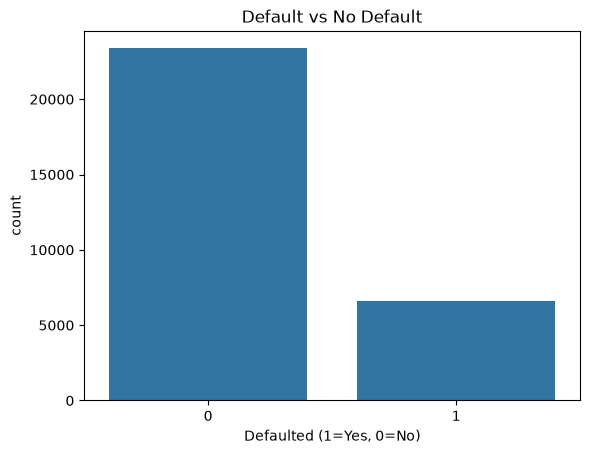

In [11]:
print(df['default.payment.next.month'].value_counts())
sns.countplot(x='default.payment.next.month', data=df)
plt.title('Default vs No Default')
plt.xlabel('Defaulted (1=Yes, 0=No)')
plt.show()

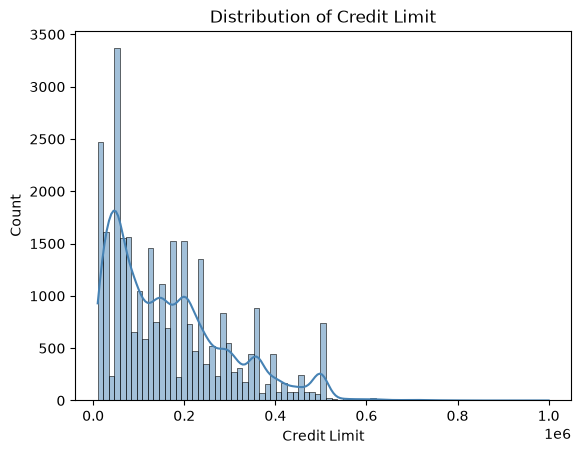

In [12]:
sns.histplot(df['LIMIT_BAL'], kde=True, color='steelblue')
plt.title('Distribution of Credit Limit')
plt.xlabel('Credit Limit')
plt.show()

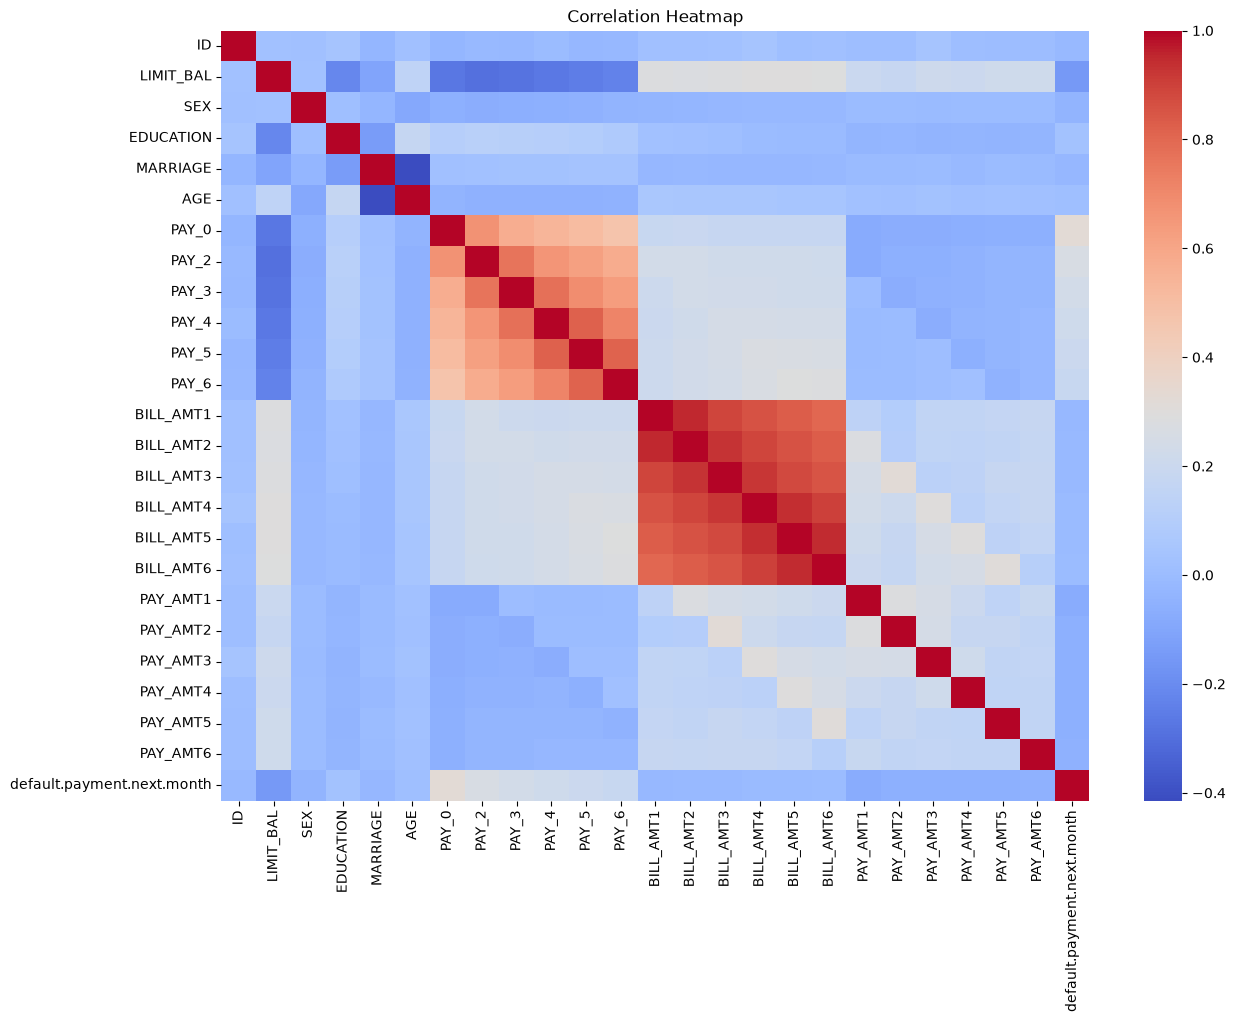

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

In [14]:
from scipy import stats

defaulted = df[df['default.payment.next.month'] == 1]['LIMIT_BAL']
not_defaulted = df[df['default.payment.next.month'] == 0]['LIMIT_BAL']

t_stat, p_value = stats.ttest_ind(defaulted, not_defaulted)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant — defaulters DO have lower credit limits")
else:
    print("Result: No significant difference")

T-statistic: -26.9085
P-value: 0.0000
Result: Statistically significant — defaulters DO have lower credit limits


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

features = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'BILL_AMT1', 'PAY_AMT1']
X = df[features]
y = df['default.payment.next.month']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_sc, y_train)
print("Model trained successfully!")

Model trained successfully!


              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.23      0.34      1313

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.61      6000
weighted avg       0.79      0.81      0.77      6000



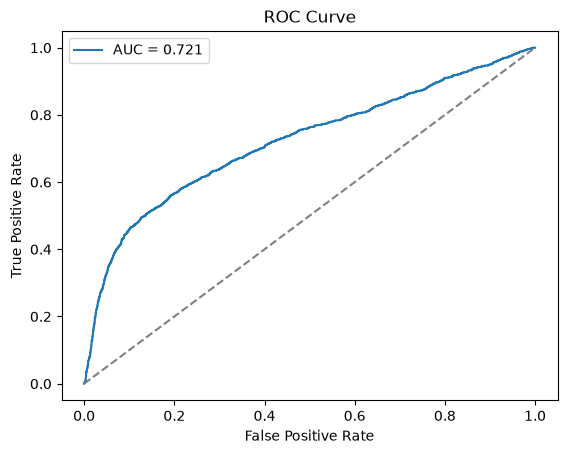

In [16]:
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

print(classification_report(y_test, model.predict(X_test_sc)))

fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test_sc)[:, 1])
auc = roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1])

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

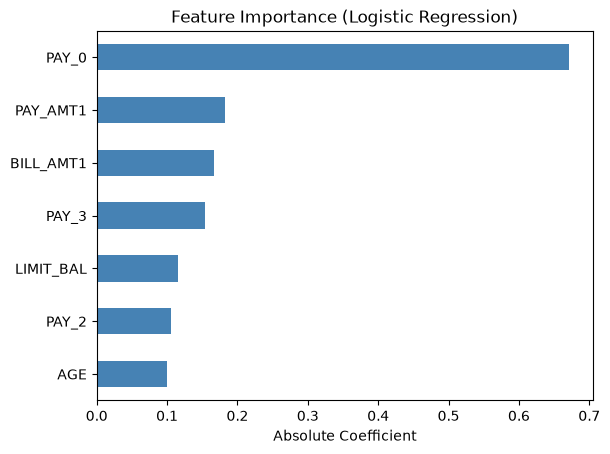

In [17]:
coefs = pd.Series(np.abs(model.coef_[0]), index=features)
coefs.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Logistic Regression)')
plt.xlabel('Absolute Coefficient')
plt.show()